# Polynomial interpolation

In [10]:
using Polynomials, Plots

## Polynomials in `julia`

In [21]:
Polynomial([1,2])


Polynomial(1 + 2*x)

In [37]:
function Lagrange(x::Vector,i::Int64) 
    l = prod( Polynomial([-x[k], 1]) for k in eachindex(x) if k ≠ i )
    return l/l(x[i])
end

Lagrange (generic function with 2 methods)

In [38]:
Lagrange([-1,1],1), Lagrange([-1,1],2)

(Polynomial(0.5 - 0.5*x), Polynomial(0.5 + 0.5*x))

In [43]:
interpolation(f::Function, x::Vector)::Polynomial = sum( f(x[k])*Lagrange(x,k) for k in eachindex(x))

interpolation (generic function with 2 methods)

## Interpolation on equi-distant and Chebyshev nodes

In [17]:
x_equi(N) = collect(LinRange(-1,1,N+1))
x_Cheb(N) = [cos( (2k+1)*π/(2N+2) ) for k = 0:N]

x_Cheb (generic function with 1 method)

In [12]:
collect(x_equi(2)), x_Cheb(2)

([-1.0, 0.0, 1.0], [0.8660254037844387, 6.123233995736766e-17, -0.8660254037844387])

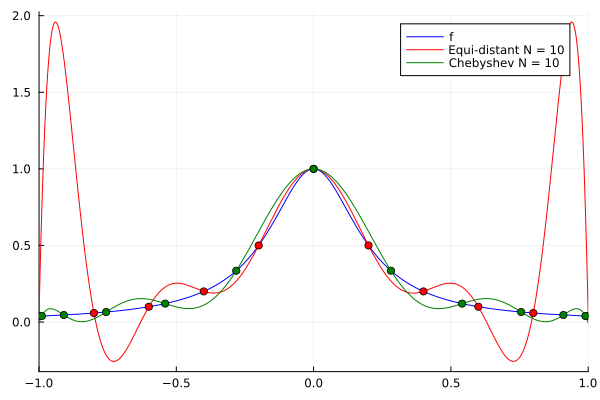

In [ ]:
f(x) = 1 / (1 + 25*x^2) # Runge's function
N = 10

plot()
plot!(f, xlims=(-1,1), label="f", color=:blue)

color=:red
x_inter = x_equi(N)
fh(x) = interpolation(f, x_inter)(x)
plot!(fh, xlims=(-1,1), label="Equi-distant N = $N", color=color)
scatter!(x_inter, f.(x_inter), label="", color=color)

color=:green
x_inter = x_Cheb(N)
fh(x) = interpolation(f, x_inter)(x)
plot!(fh, xlims=(-1,1), label="Chebyshev N = $N", color=color)
scatter!(x_inter, f.(x_inter), label="", color=color)

# Convergence graph

In [78]:
L∞(u::Function) = maximum(abs.(u.(-1:1e-2:1)))
L∞(x->exp(x)) ≈ exp(1), L∞(x -> sin(2*π*x)) ≈ 1.

(true, true)

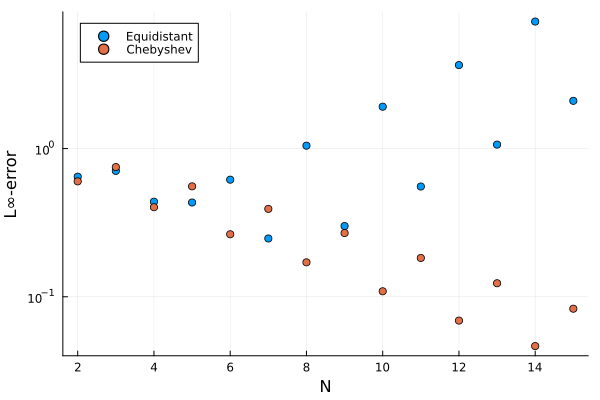

In [96]:
Ns = 2:1:15
errors_equi = zeros(length(Ns))
errors_Cheb = zeros(length(Ns))

f(x) = 1 / (1 + 25*x^2)
for (i,N) in enumerate(Ns)
    x_inter = x_equi(N)
    fh(x) = interpolation(f, x_inter)(x)
    errors_equi[i] = L∞(x -> f(x) - fh(x))

    x_inter = x_Cheb(N)
    fh(x) = interpolation(f, x_inter)(x)
    errors_Cheb[i] = L∞(x->f(x) - fh(x))
end

plot(yscale=:log10, xlabel="N", ylabel="L∞-error")
scatter!(Ns, errors_equi,label="Equidistant")
scatter!(Ns, errors_Cheb,label="Chebyshev")

# The effect of rounding error

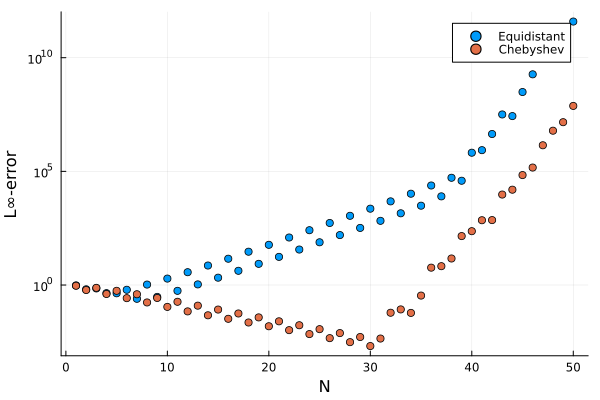

In [109]:
Ns = 1:50
errors_equi = zeros(length(Ns))
errors_Cheb = zeros(length(Ns))

f(x) = 1 / (1 + 25*x^2)
for (i,N) in enumerate(Ns)
    x_inter = x_equi(N)
    fh(x) = interpolation(f, x_inter)(x)
    errors_equi[i] = L∞(x -> f(x) - fh(x))

    x_inter = x_Cheb(N)
    fh(x) = interpolation(f, x_inter)(x)
    errors_Cheb[i] = L∞(x->f(x) - fh(x))
end

plot(yscale=:log10, xlabel="N", ylabel="L∞-error")
scatter!(Ns, errors_equi,label="Equidistant")
scatter!(Ns, errors_Cheb,label="Chebyshev")